# Máquinas Térmicas - Lección 5
## Modelación de la Combustión

**Autor:** Camilo Bayona  
**Fecha:** 12/08/2025

###Objetivos de aprendizaje

Al finalizar esta lección, el/la estudiante será capaz de:

1. Explicar los fundamentos de termoquímica de la combustión (HHV/LHV, estequiometría y exceso de aire $\lambda$).

2. Balancear reacciones globales de combustibles típicos (gaseosos y líquidos) y determinar mezclas estequiométricas y no estequiométricas a partir de composiciones dadas.

3. Formular y resolver balances de masa y energía para una cámara de combustión ideal (mezcla perfecta, 0D) bajo supuestos isobáricos e isocóricos.

4. Implementar en Python un modelo 0D con cinética global (una etapa) para predecir conversión, liberación de calor $\dot{Q}$ y fracciones másicas $Y_i(t)$.

5. Calcular propiedades de mezcla (masas molares, $x_i$, $Y_i$, $c_p$ de mezcla) con notación unificada y unidades consistentes (SI).

6. Evaluar indicadores de desempeño (rendimiento térmico, consumo específico de combustible, relación aire–combustible) y contrastar con casos de referencia.

7. Entender el proceso experimental de medición de la composición química de los combustibles.


#1. Modelación de la Combustión
Este cuaderno se centrará en la modelación matemática para representar la combustión. Preliminarmente tenemos que recordar los balances estequiométricos (Resolviendo un Sistema de Ecuaciones Algebraicas)

###1.1 Balance de Masa (estequiométrico)

El balance estequiométrico es un método fundamental para analizar reacciones químicas, garantizando que la cantidad de masa se conserve en ambos lados de la ecuación. Esto implica que los átomos de cada elemento presentes en los reactivos deben ser iguales a los presentes en los productos. Para resolverlo, podemos plantear un sistema de ecuaciones algebraicas que corresponden a la conservación de cada uno de los elementos.

Consideremos la siguiente reacción genérica de combustión de un hidrocarburo $C_xH_y$ con oxígeno:

$
C_xH_y + O_2 \rightarrow CO_2 + H_2O
$

Nuestro objetivo es balancear esta reacción mediante un sistema de ecuaciones. Los coeficientes estequiométricos a determinar son: $a$ para $C_xH_y$, $b$ para $O_2$, $c$ para $CO_2$ y $d$ para $H_2O$. La reacción química balanceada se expresa de la siguiente manera:

$
aC_xH_y + bO_2 \rightarrow cCO_2 + dH_2O
$

Para realizar el balance estequiométrico, debemos aplicar la conservación de los átomos de cada elemento en ambos lados de la ecuación.

El número de átomos de carbono en los reactivos es $a  x$, y en los productos es $c$. Por lo tanto, la ecuación correspondiente al carbono es:

$
a x = c
$

El número de átomos de hidrógeno en los reactivos es $a y$, y en los productos es $2d$ (cada molécula de $H_2O$ contiene 2 átomos de hidrógeno). Entonces, la ecuación para el hidrógeno es:

$
a y = 2d
$

En los reactivos, el número de átomos de oxígeno es $2b$(porque cada molécula de $O_2$ contiene 2 átomos). En los productos, tenemos $2c$ átomos de oxígeno de $CO_2$ y $d$ átomos de $H_2O$. La ecuación para el oxígeno es:

$
2b = 2c + d
$

Ahora tenemos un sistema de tres ecuaciones:

$
\begin{aligned}
a  x &= c \\
a  y &= 2d \\
2b &= 2c + d
\end{aligned}
$

1. Despejamos $c$ de la primera ecuación:
$
c = a  x
$
2. Despejamos $d$ de la segunda ecuación:
$
d = \frac{a  y}{2}
$
3. Sustituimos $c$ y $d$ en la tercera ecuación:
$
2b = 2(a x) + \frac{a y}{2}
$

Resolviendo para $b$, obtenemos el valor de todos los coeficientes estequiométricos.


##2. Velocidad de reacción

La velocidad de reacción está conformada por la velocidad de formación y la velocidad de descomposición. Esta velocidad no es constante y depende de varios factores, como la concentración de los reactivos, la presencia de un catalizador, la temperatura de reacción y el estado físico de los reactivos.

Uno de los factores más importantes es la concentración de los reactivos. Cuanto más partículas existan en un volumen, más colisiones hay entre las partículas por unidad de tiempo. Al principio, cuando la concentración de reactivos es mayor, también es mayor la probabilidad de que se den colisiones entre las moléculas, y la velocidad es mayor. A medida que la reacción avanza, al ir disminuyendo la concentración de los reactivos, disminuye la probabilidad de colisión y con ella la velocidad de la reacción. La medida de la rapidez de reacción implica la medida de la concentración de uno de los reactivos o productos a lo largo del tiempo, esto es, para medir la velocidad de una reacción necesitamos medir, bien la cantidad de reactivo que desaparece por unidad de tiempo, o bien la cantidad de producto que aparece por unidad de tiempo. La velocidad de reacción se mide en unidades de concentración/tiempo, esto es, en (mol/L)/s, es decir, mol/(L·s).

Para una reacción de la forma:

$$\mathrm{A \ \longrightarrow \ B + C}$$

la ley de la velocidad de formación es la siguiente:

$$v_{\mathrm r} = - \frac{\mathrm{d} c_{\mathrm{A}}}{\mathrm{d}t}$$

$v_{\mathrm r}$ es la velocidad de la reacción, $(- \mathrm{d}c_{\mathrm{A}})$ la disminución de la concentración del reactivo $\rm A$ en un tiempo $\mathrm{d}t$. Esta velocidad es la velocidad media de la reacción, pues todas las moléculas necesitan tiempos distintos para reaccionar.

La velocidad de aparición del producto es igual a la velocidad de desaparición del reactivo. De este modo, la ley de la velocidad se puede escribir de la siguiente forma:

$$v_{\mathrm r} = - \frac{\mathrm{d}c_{\mathrm{A}}}{\mathrm{d}t} = \frac{\mathrm{d}c_{\mathrm{B}}}{\mathrm{d}t} = \frac{\mathrm{d}c_{\mathrm{C}}}{\mathrm{d}t}$$

Este modelo necesita otras simplificaciones con respecto a:

* la actividad química, es decir, la "concentración efectiva"
* la cantidad de los reactivos en proporción a la cantidad de los productos y del disolvente
* la temperatura
* la energía de colisión
* presencia de catalizadores
* la presión parcial de gases



Para una reacción hipotética de la forma:

$$a\mathrm{A} + b\mathrm{B} \longrightarrow g\mathrm{G} + h\mathrm{H}$$

La velocidad de reacción se define como la siguiente expresión en caso de que sea una reacción simple molecular, como la del caso anterior:

$$ v=k\mathrm{[A]}^\alpha\mathrm{[B]}^\beta$$

las concentraciones de reactivos están elevados a su correspondiente coeficiente cinético sólo en el caso en el que la reacción sea elemental. Donde los corchetes denotan la concentración de cada una de las especies; $v$ denota la velocidad de reacción y $k$ es la constante cinética.
La velocidad de las reacciones químicas abarca escalas de tiempo muy amplias. Por ejemplo, una explosión puede ocurrir en menos de un segundo; la cocción de un alimento puede tardar minutos u horas.

Entre los varios factores que afectan la velocidad de una reacción química: la concentración de los reactivos, el grado de división, la temperatura, la existencia de catalizadores y la superficie de contactos tanto de los reactivos como del catalizador, una muy importante es la Temperatura de la reacción. Los catalizadores también pueden aumentar o disminuir la velocidad de reacción.



###2.1 Reacción en función de la temperatura
Por norma general, la velocidad de reacción aumenta con la temperatura porque incrementa la energía cinética de las moléculas. Con mayor energía cinética, las moléculas se mueven más rápido y chocan con más frecuencia y con más energía. El comportamiento de la constante de velocidad o constante de rapidez/coeficiente cinético frente a la temperatura se describe como $\ln [A] = \left ( \frac{E_a}{R} \right )\left ( \frac{1}{T_2}-\frac{1}{T_1}  \right)$ esta ecuación linealizada es muy útil y puede ser descrita a través de la ecuación de Arrhenius:

$$K = A{\mathrm{e}}^{(-E_{\rm a}/RT)}$$

donde:
* $K$ es la constante de la rapidez
* $A$ es el factor de frecuencia
* $E_{\rm a}$ es la energía de activación necesaria
* $T$ es la temperatura

Al linealizarla se obtiene que el logaritmo neperiano de la constante de rapidez es inversamente proporcional a la temperatura, como sigue: $\ln\left ( \frac{k_1}{k_2} \right )
$ la hora de calcular la energía de activación experimentalmente, ya que la pendiente de la recta obtenida al graficar la mencionada ley es: $-\frac{E_a}{R}$, haciendo un simple despeje se obtiene fácilmente esta energía de activación, tomando en cuenta que el valor de la constante universal de los gases es 1.987cal/K mol. Para un buen número de reacciones químicas la rapidez se duplica aproximadamente cada diez grados centígrados.

#3. El modelo epidémico SIR - Modelo Lotka Volterra

Una descripción matemática simple de la propagación de una enfermedad en una población es el llamado modelo SIR, que divide la población (fija) de $N$ individuos en tres "compartimentos" que pueden variar en función del tiempo, $t$:

- $S(t)$ son aquellos susceptibles pero aún no infectados con la enfermedad.
- $I(t)$ es el número de individuos infecciosos.
- $R(t)$ son aquellos individuos que se han recuperado de la enfermedad y ahora tienen inmunidad a ella.

El modelo SIR describe el cambio en la población de cada uno de estos compartimentos en términos de dos parámetros, $\beta$ y $\gamma$. $\beta$ describe la <em>tasa de contacto</em> efectiva de la enfermedad: un individuo infectado entra en contacto con $\beta N$ otros individuos por unidad de tiempo (de los cuales la fracción que son susceptibles a contraer la enfermedad es $S/N$). $\gamma$ es la tasa media de recuperación: es decir, $1/\gamma$ es el período medio de tiempo durante el cual un individuo infectado puede transmitirlo.

Las ecuaciones diferenciales que describen este modelo fueron derivadas por primera vez por Kermack y McKendrick [Proc. R. Soc. A, <strong>115</strong>, 772 (1927)]:

\begin{align}
\frac{\mathrm{d}S}{\mathrm{d}t} &= -\frac{\beta S I}{N},\\
\frac{\mathrm{d}I}{\mathrm{d}t} &= \frac{\beta S I}{N} - \gamma I,\\
\frac{\mathrm{d}R}{\mathrm{d}t} &= \gamma I.
\end{align}

El siguiente código de Python integra estas ecuaciones para una enfermedad caracterizada por los parámetros $\beta = 0.2$, $1/\gamma = 10;\mathrm{días}$ en una población de $N=1000$ (quizás el COVID en un curso universitario). El modelo se inicia con un solo individuo infectado en el día 0: $I(0)=1$. Las curvas trazadas de $S(t)$, $I(t)$ y $R(t)$ tienen un estilo de gráfica un poco más agradable que los valores predeterminados de Matplotlib.

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Total population, N.
N = 1000
# Initial number of infected and recovered individuals, I0 and R0.
I0, R0 = 1, 0
# Everyone else, S0, is susceptible to infection initially.
S0 = N - I0 - R0
# Contact rate, beta, and mean recovery rate, gamma, (in 1/days).
beta, gamma = 0.5, 1./10
# A grid of time points (in days)
t = np.linspace(0, 160, 160)

# The SIR model differential equations.
def deriv(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# Initial conditions vector
y0 = S0, I0, R0
# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(N, beta, gamma))
S, I, R = ret.T

# Plot the data on three separate curves for S(t), I(t) and R(t)
fig = plt.figure(facecolor='w')
ax = fig.add_subplot(111, facecolor='#dddddd', axisbelow=True)
ax.plot(t, S/1000, 'b', alpha=0.5, lw=2, label='Susceptible')
ax.plot(t, I/1000, 'r', alpha=0.5, lw=2, label='Infected')
ax.plot(t, R/1000, 'g', alpha=0.5, lw=2, label='Recovered with immunity')
ax.set_xlabel('Time /days')
ax.set_ylabel('Number (1000s)')
ax.set_ylim(0,1.2)
ax.yaxis.set_tick_params(length=0)
ax.xaxis.set_tick_params(length=0)
ax.grid(which='major', c='w', lw=2, ls='-')
legend = ax.legend()
legend.get_frame().set_alpha(0.5)
for spine in ('top', 'right', 'bottom', 'left'):
    ax.spines[spine].set_visible(False)
plt.show()

## 4.  Balance de Energía Térmica
La energía térmica neta producida por la combustión se puede calcular utilizando la entalpía de formación de las moléculas involucradas en la reacción. La entalpía de formación es la energía requerida para formar una molécula a partir de sus elementos constituyentes en su estado estándar.

###4.1 Entalpía de formación

La variación de entalpía estándar de formación se usa en termoquímica para encontrar la variación de entalpía estándar de reacción. Esto se hace restándole la suma de las entalpías estándar de formación de los reactivos a la suma de las entalpías estándar de formación de los productos, como se muestra en la siguiente ecuación:

Δ''H''<sup>O</sup><sub>r</sub> = ΣΔ''H''<sup>O</sup><sub>f</sub> (Productos) - ΣΔ''H''<sup>O</sup><sub>f</sub> (Reactivos)

donde:

* <sup>O</sup> significa "estándar"
* <sub>r</sub> "de reacción"
* <sub>f</sub> "de formación"

La energía térmica neta, o calor de la reacción, se calcula como la diferencia entre la entalpía de los productos y la entalpía de los reactantes. En este caso, como los reactantes están en su estado estándar, sus entalpías de formación son cero. Por lo tanto, la energía térmica neta es simplemente el negativo de la entalpía de formación de los productos multiplicada por el número de moles de los productos.

### 4.2 Poder Calorífico
El poder calorífico es la cantidad de energía liberada por la combustión de una unidad de masa de combustible. Se puede calcular integrando la potencia térmica en el tiempo y dividiéndola por la masa del combustible. En este caso, la potencia térmica es simplemente la energía térmica neta dividida por el tiempo de la reacción. Si asumimos que la reacción ocurre instantáneamente, entonces el poder calorífico es simplemente la energía térmica neta dividida por la masa del combustible quemado.

###4.3 Modelo Matemático Símple

El poder calorífico del combustible nos permite establecer el modelo más simple de combustión. En ese modelo, la cantidad de calor liberado durante la combustión completa de una cantidad específica de combustible se mide en unidades de energía por unidad de masa, como joules por gramo (J/g) o kilocalorías por gramo (kcal/g).

A nivel experimental el calor de combustión se puede determinar utilizando una bomba calorimétrica, que es un dispositivo que mide el calor liberado durante una reacción química.

El calor de combustión se puede calcular utilizando la siguiente fórmula:

$$ Q_f = m_f \cdot LHV$$

Donde:

- $Q_f$ es el calor de combustión,
- $m_f$ es la masa del combustible y
- $LHV$ es el poder calorífico (inferior) del combustible.

###4.4 Eficiencia de combustión

La eficiencia de combustión se refiere a la capacidad de un combustible para convertir su energía potencial en energía útil. Se mide como la relación entre la energía liberada durante la combustión y la energía total contenida en el combustible.

La eficiencia de combustión puede ser afectada por varios factores, incluyendo la calidad del combustible, las condiciones de combustión (oxígeno disponible para completar la combustión) y el diseño del sistema de combustión.

La eficiencia de combustión se puede calcular utilizando la siguiente fórmula:

$$ \eta = \frac{Q_{f}}{Q_{ch}} $$

Donde:

- $\eta$ es la eficiencia de combustión,
- $Q_f$ es la energía liberada durante la combustión, y
- $Q_{ch}$ es la energía total contenida en el combustible.

##4. Reacción de Oxidación del Hidrógeno
La reacción de oxidación del hidrógeno es una reacción química fundamental en la combustión. La reacción es la siguiente:

$$2H_2 + O_2 \rightarrow 2H_2O$$

###4.1 Modelo de Cinética de Reacción de la Oxidación del Hidrógeno
Ahora vamos a modelar la cinética de la reacción de oxidación del hidrógeno utilizando un modelo SIR. En este modelo, las cantidades S, I y R representarán las concentraciones de H2, O2 y H2O, respectivamente. Las ecuaciones diferenciales del modelo SIR son las siguientes:

$$\frac{d[H2]}{dt} = -\beta \cdot \frac{[H2] \cdot [O2]}{N}$$
$$\frac{d[O2]}{dt} = \beta \cdot \frac{[H2] \cdot [O2]}{N} - \gamma \cdot [O2]$$
$$\frac{d[H2O]}{dt} = \gamma \cdot [O2]$$

Donde:
- $\beta$ es la tasa de reacción entre H2 y O2.
- $\gamma$ es la tasa de formación de H2O.
- N es la concentración total de moléculas.

In [ ]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt


# The SIR model differential equations.
def deriv(y, t, N, beta, gamma):
    H2, O2, H2O = y
    dH2dt = -beta * H2 * O2 / N
    dO2dt = -beta * H2 * O2 / N - gamma * O2
    dH2Odt = beta * H2 * O2 / N
    return dH2dt, dO2dt, dH2Odt

N = 1000
beta = 0.2
gamma = 0.1

# Initial conditions vector
y0 = H20, O20, H2O0 = 700, 300, 0
# A grid of time points (in seconds)
t = np.linspace(0, 40, 40)

# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(N, beta, gamma))
H2, O2, H2O = ret.T

# Plot the data on three separate curves for H2(t), O2(t) and H2O(t)
fig = plt.figure(facecolor='w')
ax = fig.add_subplot(111, facecolor='#dddddd', axisbelow=True)
ax.plot(t, H2/1000, 'b', alpha=0.5, lw=2, label='H2')
ax.plot(t, O2/1000, 'r', alpha=0.5, lw=2, label='O2')
ax.plot(t, H2O/1000, 'g', alpha=0.5, lw=2, label='H2O')
ax.set_xlabel('Time ')
ax.set_ylabel('Concentration')
ax.set_ylim(0,1.2)
ax.yaxis.set_tick_params(length=0)
ax.xaxis.set_tick_params(length=0)
ax.grid(which='major', c='w', lw=2, ls='-')
legend = ax.legend()
legend.get_frame().set_alpha(0.5)
for spine in ('top', 'right', 'bottom', 'left'):
    ax.spines[spine].set_visible(False)
plt.show()

###4.2  Energía Térmica Neta


In [ ]:
# Definimos las entalpías de formación a 298 K para los compuestos relevantes
# Los valores se obtienen de tablas termodinámicas y se dan en J/mol
Hf_CO2 = -393509.0  # CO2
Hf_H2O = -241826.0  # H2O
Hf_O2 = 0.0  # O2
Hf_N2 = 0.0  # N2
Hf_C = 0.0  # C
Hf_S = 0.0  # S
Hf_H2 = 0.0  # H2

# Cálculo del poder calorífico del combustible
# El poder calorífico es la diferencia entre la entalpía de formación de los productos y los reactivos
# Para la combustión de 1 mol de carbono a CO2
delta_H_C = Hf_CO2 - Hf_C - Hf_O2
# Para la combustión de 1 mol de hidrógeno a H2O
delta_H_H2 = Hf_H2O - Hf_H2 - 0.5 * Hf_O2

# El poder calorífico del combustible es la suma de los poderes caloríficos de sus componentes
PC = delta_H_C + delta_H_H2
PC

In [ ]:
Hf_H2O = -241826.0  # H2O
Hf_O2 = 0.0  # O2
Hf_H2 = 0.0  # H2

# Cálculo del poder calorífico del combustible
# El poder calorífico es la diferencia entre la entalpía de formación de los productos y los reactivos
# Para la combustión de 1 mol de hidrógeno a H2O
delta_H_H2 = Hf_H2O - Hf_H2 - 0.5 * Hf_O2

# El poder calorífico del combustible es la suma de los poderes caloríficos de sus componentes
PC = delta_H_H2
PC

Para el agua en estado gaseoso, la entalpía de formación es de -241.8 kJ/mol.

La energía térmica neta, o calor de la reacción, se calcula como la diferencia entre la entalpía de los productos y la entalpía de los reactantes. En este caso, como los reactantes (hidrógeno y oxígeno) están en su estado estándar, sus entalpías de formación son cero. Por lo tanto, la energía térmica neta es simplemente el negativo de la entalpía de formación del agua multiplicada por el número de moles de agua producidos, que es 2 en este caso. Esto da:

$$Q = -2 \times (-241.8\,kJ/mol) = 483.6\,kJ$$

###4.3 Poder Calorífico del Hidrógeno

La masa molar del hidrógeno es de 2 g/mol (dos átomos por molécula). Por lo tanto, para 2 moles de hidrógeno, la masa es de 4 g. Esto da un poder calorífico de:

$$PC = \frac{Q}{m} = \frac{483.6\,kJ}{4\,g} = 120.5\,kJ/g$$

##5. Oxidación del Carbono
Ahora vamos a modelar la oxidación del carbono. La reacción es la siguiente:

$$C + O_2 \rightarrow CO_2$$

In [ ]:
# The SIR model differential equations for Carbon Combustion
def deriv_carbon(y, t, N, beta, gamma):
    C, O2, CO2 = y
    dCdt = -beta * C * O2 / N
    dO2dt = beta * C * O2 / N - gamma * O2
    dCO2dt = gamma * O2
    return dCdt, dO2dt, dCO2dt

# Initial conditions vector
y0 = S0, I0, R0 = 700, 300, 0
# A grid of time points (in seconds)
t = np.linspace(0, 40, 40)
N = 1000
beta = 0.2
gamma = 0.1

# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv_carbon, y0, t, args=(N, beta, gamma))
C, O2, CO2 = ret.T

In [ ]:
# Plot the data on three separate curves for H2(t), O2(t) and H2O(t)
fig = plt.figure(facecolor='w')
ax = fig.add_subplot(111, facecolor='#dddddd', axisbelow=True)
ax.plot(t, C/1000, 'b', alpha=0.5, lw=2, label='C')
ax.plot(t, O2/1000, 'r', alpha=0.5, lw=2, label='O_2')
ax.plot(t, CO2/1000, 'g', alpha=0.5, lw=2, label='CO2')
ax.set_xlabel('Time ')
ax.set_ylabel('Concentration')
ax.set_ylim(0,1.2)
ax.yaxis.set_tick_params(length=0)
ax.xaxis.set_tick_params(length=0)
ax.grid(which='major', c='w', lw=2, ls='-')
legend = ax.legend()
legend.get_frame().set_alpha(0.5)
for spine in ('top', 'right', 'bottom', 'left'):
    ax.spines[spine].set_visible(False)
plt.show()

In [ ]:
# Definimos las entalpías de formación a 298 K para los compuestos relevantes
# Los valores se obtienen de tablas termodinámicas y se dan en J/mol
Hf_CO2 = -393509.0  # CO2
Hf_O2 = 0.0  # O2
Hf_C = 0.0  # C

# Cálculo del poder calorífico del combustible
# El poder calorífico es la diferencia entre la entalpía de formación de los productos y los reactivos
# Para la combustión de 1 mol de carbono a CO2
delta_H_C = Hf_CO2 - Hf_C - Hf_O2


# El poder calorífico del combustible es la suma de los poderes caloríficos de sus componentes
PC = delta_H_C
PC

In [ ]:
# Ejercicio: calcular el poder calorífico de este combustible

## 6. Oxidación del Azufre
Finalmente, vamos a modelar la oxidación del azufre. La reacción es la siguiente:

$$S + O_2 \rightarrow SO_2$$

In [ ]:
# The SIR model differential equations for Sulfur Combustion
def deriv_sulfur(y, t, N, beta, gamma):
    S, O2, SO2 = y
    dSdt = -beta * S * O2 / N
    dO2dt = beta * S * O2 / N - gamma * O2
    dSO2dt = gamma * O2
    return dSdt, dO2dt, dSO2dt

# Initial conditions vector
y0 = S0, I0, R0 = 700, 300, 0
t = np.linspace(0, 40, 40)
N = 1000
beta = 0.2
gamma = 0.1

# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv_sulfur, y0, t, args=(N, beta, gamma))
S, O2, SO2 = ret.T

In [ ]:
# Plot the data on three separate curves for H2(t), O2(t) and H2O(t)
fig = plt.figure(facecolor='w')
ax = fig.add_subplot(111, facecolor='#dddddd', axisbelow=True)
ax.plot(t, S/1000, 'b', alpha=0.5, lw=2, label='S')
ax.plot(t, O2/1000, 'r', alpha=0.5, lw=2, label='O_2')
ax.plot(t, SO2/1000, 'g', alpha=0.5, lw=2, label='SO2')
ax.set_xlabel('Time ')
ax.set_ylabel('Concentration')
ax.set_ylim(0,1.2)
ax.yaxis.set_tick_params(length=0)
ax.xaxis.set_tick_params(length=0)
ax.grid(which='major', c='w', lw=2, ls='-')
legend = ax.legend()
legend.get_frame().set_alpha(0.5)
for spine in ('top', 'right', 'bottom', 'left'):
    ax.spines[spine].set_visible(False)
plt.show()

In [ ]:
# Ejercicio: calcular el poder calorífico de este combustible

##7. Composición del Aire
El aire es una mezcla de gases que consiste principalmente en nitrógeno (N2) y oxígeno (O2). El nitrógeno constituye aproximadamente el 78% del volumen del aire seco, mientras que el oxígeno constituye aproximadamente el 21%. El 1% restante está compuesto por argón (Ar), dióxido de carbono (CO2), neón (Ne), helio (He) y otros gases traza.

Además de estos gases, el aire también puede contener una cantidad variable de vapor de agua, que puede constituir hasta alrededor del 1% del volumen del aire en condiciones húmedas.

Es importante tener en cuenta que aunque el oxígeno constituye sólo alrededor del 21% del aire, es el componente clave para la mayoría de las reacciones de combustión.

###7.1 Combustión del Carbono con Aire
La combustión del carbono con aire implica la reacción del carbono (C) con el oxígeno (O2) presente en el aire para formar dióxido de carbono (CO2). La reacción es exotérmica, lo que significa que libera energía en forma de calor. A condiciones estándar, la reacción es la siguiente:

$$C + O_2 + 3.76N_2 \rightarrow CO_2 + 3.76N_2$$

Es importante tener en cuenta que aunque el aire contiene nitrógeno, el nitrógeno no participa en la reacción de combustión a menos que la temperatura sea lo suficientemente alta. A temperaturas muy altas, el nitrógeno puede reaccionar con el oxígeno para formar óxidos de nitrógeno, pero esto generalmente no ocurre en la mayoría de las condiciones de combustión.

###7.2 Balance general de la Combustión del Carbono con Aire
Para realizar un balance químico de la combustión del carbono con aire, debemos tener en cuenta que el aire es una mezcla de gases que contiene aproximadamente 78% de nitrógeno (N2) y 21% de oxígeno (O2) por volumen. Por lo tanto, para cada mol de oxígeno en el aire, hay aproximadamente 3.76 moles de nitrógeno. Esto significa que para cada mol de carbono que reacciona con el oxígeno en el aire, también hay 3.76 moles de nitrógeno presentes.

La reacción de combustión del carbono con aire, incluyendo el nitrógeno, es la siguiente:

$$C_m + m(O_2 + 3.76N_2) \rightarrow mCO_2 + m3.76N_2$$

Como puedes ver, el nitrógeno aparece en ambos lados de la ecuación, lo que indica que no reacciona durante la combustión del carbono a condiciones estándar. El nitrógeno se considera un gas inerte en esta reacción.

In [ ]:
# Ejercicio: calcular el poder calorífico de este combustible

##8. Relación Aire Combustible
La relación aire-combustible (A/F) es una medida importante en muchos procesos de combustión, incluyendo la combustión de carbono. Esta relación se define como la proporción de la cantidad de aire al combustible presente en una mezcla de combustión.

###8.1 A/F del Carbono con Aire

En la combustión completa, cada mol de carbono requiere 1 mol de oxígeno para reaccionar completamente y formar dióxido de carbono. Sin embargo, como el aire es una mezcla de gases que contiene aproximadamente 21% de oxígeno y 78% de nitrógeno, para cada mol de oxígeno en el aire, hay aproximadamente 3.76 moles de nitrógeno. Por lo tanto, para cada mol de carbono, se requieren aproximadamente 4.76 moles de aire (1 mol de oxígeno + 3.76 moles de nitrógeno) para la combustión completa.

Por lo tanto, la relación aire-combustible para la combustión completa del carbono es de aproximadamente 4.76:1. Esto significa que se requieren 4.76 moles de aire para quemar completamente 1 mol de carbono.

Es importante tener en cuenta que esta es la relación aire-combustible estequiométrica, que es la relación para la combustión completa. En la práctica, la relación aire-combustible puede ser mayor o menor que la relación estequiométrica, dependiendo de las condiciones específicas de la combustión.

In [ ]:
# Ejercicio: calcular la relación aire combustible de este combustible

### Soución:

AFR Estequiométrico:
$
\frac{\text{Masa de Aire}}{\text{Masa de } C} = \frac{32 \, \text{g/mol} + 3.76 \times 28 \, \text{g/mol}}{12 \, \text{g/mol}} = \frac{137.28 \, \text{g/mol}}{12 \, \text{g/mol}} \approx 11.44 \, \text{kg de aire/kg de combustible}
$


Cuando \( m > n \)

$
mC + n(O_2 + 3.76 N_2) \rightarrow n CO_2 + n 3.76 N_2 + (m - n)C
$

Cuando \( m < n \)

$
mC + n(O_2 + 3.76 N_2) \rightarrow m CO_2 + n 3.76 N_2 - (m - n) O_2
$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Parámetros
mass_C = 12 # Masa molar de C en g/mol
mass_O2 = 32 # Masa molar de O2 en g/mol
mass_N2 = 28 # Masa molar de N2 en g/mol
Hf_co2 = -393.5 # Entalpía de formaciónn de CO2 KJ/mol
Hf_c = 0 # Entalpía de formación de C J/mol
Hf_o2 = 0 # Entalpía de formación de O2 J/mol
Hf_N2 = 0 # Entalpía de formación de N2 J/mol

# Rango de moles de carbono n_C y aire n(O2+3.76N2)
n_C_range = np.arange(1, 11, 1) # Moles de carbono, de 1 a 10
n_A_range = np.arange(1, 11, 1) # Moles de Aire, de 1 a 10

# Función para encontrar el valor máximo asociado a cada número repetido
def max_associated_values(matriz1, matriz2):
  # Diccionario para almacenar el valor máximo asociado a cada número repetido
  max_valores = {}

  # Recorrer las matrices
  for i in range(len(matriz1)):
    for j in range(len(matriz1[0])):

      num = matriz1[i][j]
      valor = matriz2[i][j]
      # Si el número ya está en el diccionario, actualiza con el valor máximo
      if num in max_valores:
        max_valores[num] = max(max_valores[num], valor)
      else: max_valores[num] = valor
  return max_valores

# Crear la matriz para almacenar el calor liberado
calor_liberado_matrix = np.zeros((len(n_C_range), len(n_A_range)))
# Crear la matriz para almacenar el AFR
AFR_matrix = np.zeros((len(n_C_range), len(n_A_range)))

# Llenar las matrices con los valores de calor liberado y AFR
for i, n_C in enumerate(n_C_range):
  for j, n_A in enumerate(n_A_range):
    # Calcular el AFR actual
    AFR_actual = (n_A * (mass_O2 + 3.76 * mass_N2)) / (n_C * mass_C)
    AFR_matrix[i, j] = AFR_actual

    # Calor liberado si hay mayor presencia de combustible
    if i > j:
       calor_liberado = n_C * Hf_c + n_A * (Hf_o2 + 3.76*Hf_N2) - n_A * Hf_co2 #J
       calor_liberado_matrix[i, j] = (calor_liberado) / (n_C*mass_C + n_A * (mass_O2 + 3.76 * mass_N2) )

    # Calor liberado si hay mayor presencia de aire
    else :
      calor_liberado = n_C * Hf_c + n_A * (Hf_o2 + 3.76*Hf_N2) - n_C *Hf_co2 #J
      calor_liberado_matrix[i, j] = calor_liberado / (n_C*mass_C + n_A *(mass_O2 + 3.76 * mass_N2) )

# Convertir la matriz de AFR a un vector
AFR_vector = AFR_matrix.flatten()
#Eliminar elementos repetidos de valores de AFR
AFR_vector2 = np.unique(AFR_vector)
calor_liberado_vector = np.zeros(len(AFR_vector2))
max_valores = max_associated_values(AFR_matrix, calor_liberado_matrix)

#Se llena el vector de calor liberado con su respectivo AFR
for k in range(len(AFR_vector2)):
  calor_liberado_vector[k] = max_valores[AFR_vector2[k]]

fig = plt.figure(facecolor='w')
ax = fig.add_subplot(111, facecolor='#dddddd', axisbelow=True)
ax.plot(AFR_vector2, calor_liberado_vector, 'y', alpha=0.5, lw=2, label='Q')
ax.set_xlabel('AFR') #Se establece el tiempo en ms dado que las reacciónes teóricamente ocurren muy rápidamente
ax.set_ylabel('Q (KJ/g)')
ax.set_title('Calor aportado por unidad de masa para Carbono')
ax.set_ylim(0,3)
y_max = np.max(calor_liberado_vector) #Encontrar valor máximo (relación estequiométrica)
x_max = AFR_vector2[np.argmax(calor_liberado_vector)] # Encuentra el valor de x correspondiente

# Trazar una línea horizontal en el valor máximo de y
plt.axvline(x=x_max, color='g', linestyle='--', label=f'Máximo x = {x_max}') # Marcar el punto máximo en el gráfico
plt.plot(x_max, y_max, 'ro') # Marcar el punto máximo ax.yaxis.set_tick_params(length=0)
ax.xaxis.set_tick_params(length=0)
ax.grid(which='major', c='w', lw=2, ls='-')
legend = ax.legend()
legend.get_frame().set_alpha(0.5)
for spine in ('top', 'right', 'bottom', 'left'):
  ax.spines[spine].set_visible(False)
plt.show()

### 8.2 A/F del Azufre con Aire

AFR Estequiométrico:
$
\frac{\text{Masa de Aire}}{\text{Masa de } S} = \frac{32 \, \text{g/mol} + 3.76 \times 28 \, \text{g/mol}}{32 \, \text{g/mol}} = \frac{137.28 \, \text{g/mol}}{32 \, \text{g/mol}} \approx 4.29 \, \text{kg de aire/kg de combustible}
$

Cuando \( m > n \)

$
mS + n(O_2 + 3.76 N_2) \rightarrow n SO_2 + n 3.76 N_2 + (m - n) S
$

Cuando \( m < n \)

$
mS + n(O_2 + 3.76 N_2) \rightarrow m SO_2 + n 3.76 N_2 - (m - n) O_2
$

###8.3 A/F del Hidrógeno con Aire

AFR Estequiométrico:
$
\frac{\text{Masa de Aire}}{\text{Masa de } H_2} = \frac{32 \, \text{g/mol} + 3.76 \times 28 \, \text{g/mol}}{2 \times 2 \, \text{g/mol}} = \frac{137.28 \, \text{g/mol}}{4 \, \text{g/mol}} \approx 34.32 \, \text{kg de aire/kg de combustible}
$

Cuando \( 2n > m \):

$
mH_2 + n(O_2 + 3.76 N_2) \rightarrow m H_2O + n 3.76 N_2 + (2n - m) O
$

Cuando \( 2n < m \):

$
mH_2 + n(O_2 + 3.76 N_2) \rightarrow n H_2O + n 3.76 N_2 - (2n - m) H_2
$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Entalpías de formación (kJ/mol)
DeltaHf_CO2 = 393.5
DeltaHf_SO2 = 296.8
DeltaHf_H2O = 241.8
DeltaHf_C = 0
DeltaHf_S = 0
DeltaHf_H2 = 0
DeltaHf_O2 = 0

# Moles de oxígeno requeridos por mol de combustible (Estequiométrico)
n_O2_C = 1  # 1 mol de O2 por 1 mol de C
n_O2_S = 1  # 1 mol de O2 por 1 mol de S
n_O2_H = 0.5  # 0.5 mol de O2 por 1 mol de H2

# Pesos moleculares (g/mol)
MW_O2 = 32  # Oxígeno
MW_C = 12   # Carbono
MW_S = 32   # Azufre
MW_H2 = 2   # Hidrógeno

# Rango de AFR en términos de moles de aire/moles de combustible
AFR_range_moles = np.linspace(0.1, 10, 100)  # Varía desde muy rico a muy pobre

# Inicializar vectores para almacenar los valores liberados normalizados
Q_C_mass = np.zeros(len(AFR_range_moles))
Q_S_mass = np.zeros(len(AFR_range_moles))
Q_H_mass = np.zeros(len(AFR_range_moles))

# Calor liberado por cada reacción
Q_C = DeltaHf_CO2 - DeltaHf_C - DeltaHf_O2  # C + O2 -> CO2
Q_S = DeltaHf_SO2 - DeltaHf_S - DeltaHf_O2  # S + O2 -> SO2
Q_H = 2 * DeltaHf_H2O - DeltaHf_H2 - DeltaHf_O2  # H2 + O2 -> 2H2O

# Calcular el calor liberado normalizado en función del AFR
for i in range(len(AFR_range_moles)):
    AFR = AFR_range_moles[i]

    # Calor liberado normalizado para carbono (C)
    moles_O2_C = n_O2_C * AFR  # Moles de O2 disponibles
    total_mass_C = MW_C + moles_O2_C * MW_O2  # Masa total
    if AFR >= 1:  # Mezcla rica, suficiente O2
        Q_C_mass[i] = Q_C / total_mass_C
    else:  # Mezcla pobre, limitación de O2
        Q_C_mass[i] = Q_C * AFR / total_mass_C

    # Calor liberado normalizado para azufre (S)
    moles_O2_S = n_O2_S * AFR
    total_mass_S = MW_S + moles_O2_S * MW_O2
    if AFR >= 1:
        Q_S_mass[i] = Q_S / total_mass_S
    else:
        Q_S_mass[i] = Q_S * AFR / total_mass_S

    # Calor liberado normalizado para hidrógeno (H2)
    moles_O2_H = n_O2_H * AFR
    total_mass_H = MW_H2 + moles_O2_H * MW_O2
    if AFR >= 1:
        Q_H_mass[i] = Q_H / total_mass_H
    else:
        Q_H_mass[i] = Q_H * AFR / total_mass_H

# Identificar el valor de AFR estequiométrico como el punto máximo de calor liberado
idx_C = np.argmax(Q_C_mass)
idx_S = np.argmax(Q_S_mass)
idx_H = np.argmax(Q_H_mass)

AFR_C_esteq = AFR_range_moles[idx_C]
Q_C_esteq = Q_C_mass[idx_C]

AFR_S_esteq = AFR_range_moles[idx_S]
Q_S_esteq = Q_S_mass[idx_S]

AFR_H_esteq = AFR_range_moles[idx_H]
Q_H_esteq = Q_H_mass[idx_H]

# Graficar AFR vs. Calor liberado para cada combustible
plt.figure()

plt.plot(AFR_range_moles, Q_C_mass, '-o', label='Carbono (C)')
plt.plot(AFR_range_moles, Q_S_mass, '-s', label='Azufre (S)')
plt.plot(AFR_range_moles, Q_H_mass, '-x', label='Hidrógeno (H2)')

# Añadir los puntos estequiométricos a la gráfica
plt.plot(AFR_C_esteq, Q_C_esteq, 'ro', label='C (Estequiométrico)')
plt.plot(AFR_S_esteq, Q_S_esteq, 'ro', label='S (Estequiométrico)')
plt.plot(AFR_H_esteq, Q_H_esteq, 'ro', label='H2 (Estequiométrico)')

plt.xlabel('Air-Fuel Ratio (AFR) en moles')
plt.ylabel('Calor liberado (kJ/mol de masa total)')
plt.title('Curva de AFR vs. Calor Liberado')
plt.legend()
plt.grid(True)
plt.show()


## 9.Balance de la Combustión de Combustibles Generales con Aire
Para un combustible compuesto por carbono (C), hidrógeno (H), nitrógeno (N) y azufre (S), el balance molar de la combustión se puede expresar de la siguiente manera:

$$C_mH_nN_oS_p + (m + \frac{n}{4} - \frac{o}{2} + \frac{p}{2}) (O_2 + 3.76N_2) \rightarrow mCO_2 + \frac{n}{2}H_2O + \frac{o}{2}N_2 + pSO_2 + (m + \frac{n}{4} - \frac{o}{2} + \frac{p}{2})3.76N_2$$

Donde:
- $C_mH_nN_oS_p$ representa el combustible, con $m$ moles de carbono, $n$ moles de hidrógeno, $o$ moles de nitrógeno y $p$ moles de azufre.
- $O_2 + 3.76N_2$ representa el aire, con 1 mol de oxígeno y 3.76 moles de nitrógeno por cada mol de oxígeno.
- $mCO_2 + \frac{n}{2}H_2O + \frac{o}{2}N_2 + pSO_2 + (m + \frac{n}{4} - \frac{o}{2} + \frac{p}{2})3.76N_2$ son los productos de la combustión, que incluyen dióxido de carbono, agua, nitrógeno y dióxido de azufre, así como el nitrógeno que no reacciona en la combustión.

Este balance molar de la combustión asegura que cada elemento se conserva en la reacción, es decir, la cantidad de cada elemento en los reactivos es igual a la cantidad en los productos. Esto es una aplicación de la ley de conservación de la masa.

###9.1 Cálculo de la Relación Aire Combustible para Combustibles Generales
Para combustibles que contienen carbono (C), hidrógeno (H), nitrógeno (N) y azufre (S), la relación aire-combustible se calcula considerando la cantidad de oxígeno necesaria para oxidar completamente estos elementos a sus productos de combustión más estables, que son CO2, H2O, N2 y SO2, respectivamente.

Para cada mol de carbono en el combustible, se requiere 1 mol de O2 para formar CO2. Para cada mol de hidrógeno, se requiere 1/2 mol de O2 para formar H2O. El nitrógeno en el combustible generalmente se asume que se convierte en N2, que no requiere oxígeno. Para cada mol de azufre, se requiere 1 mol de O2 para formar SO2.

Por lo tanto, la cantidad total de oxígeno requerida para la combustión completa del combustible se puede calcular sumando la cantidad de oxígeno requerida para oxidar cada elemento. Luego, esta cantidad total de oxígeno se multiplica por 4.76 para obtener la cantidad total de aire requerida, ya que cada mol de oxígeno en el aire está acompañado por 3.76 moles de nitrógeno.

El poder calorífico del combustible se puede calcular a partir de la entalpía de formación de los productos de combustión y los reactivos. La entalpía de formación es la cantidad de energía liberada o absorbida cuando un compuesto se forma a partir de sus elementos constituyentes. Para la combustión, la entalpía de formación de los productos de combustión es menor que la de los reactivos, y la diferencia es la cantidad de energía liberada en la reacción, que es el poder calorífico del combustible.

In [ ]:
# Ejercicio: calcular la relación aire combustible de forma general

#### Ejemplo: Propano

$
C_3H_8 + 5(O_2 + 3.76 N_2) \rightarrow 3 CO_2 + 4 H_2O + 5 (3.76 N_2)
$

AFR Estequiométrico:
$
\frac{\text{Masa de Aire}}{\text{Masa de } C_3H_8} = \frac{5 \times (32 \, \text{g/mol} + 3.76 \times 28 \, \text{g/mol})}{44 \, \text{g/mol}} = \frac{5 \times 137.28 \, \text{g/mol}}{44 \, \text{g/mol}} \approx 15.6 \, \text{kg de aire/kg de combustible}
$

Tomando en cuenta el balance estequiométrico se llegó a los casos no ideales

Cuando \( 5m > n \):

$
m C_3H_8 + n (O_2 + 3.76 N_2) \rightarrow 3m CO_2 + (2n - 6m) H_2O + n (3.76 N_2) + (20m - 4n) H
$

Cuando \( 5m < n \):

$
m C_3H_8 + n (O_2 + 3.76 N_2) \rightarrow 3m CO_2 + 4m H_2O + n (3.76 N_2) + (2n - 10m) O
$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Parámetros
mass_C3H8 = 44  # Masa molar de C3H8 en g/mol
mass_O2 = 32  # Masa molar de O2 en g/mol
mass_N2 = 28  # Masa molar de N2 en g/mol
Hf_C3H8 = -103.8  # Entalpía de formación de C3H8 KJ/mol
Hf_CO2 = -393.5  # Entalpía de formación de CO2 KJ/mol
Hf_H2O = -292.6  # Entalpía de formación de H2O KJ/mol
Hf_O2 = 0  # Entalpía de formación de O2 KJ/mol
Hf_N2 = 0  # Entalpía de formación de N2 KJ/mol

# Rango de moles de propano C3H8 y aire n(O2+3.76N2)
n_C3H8_range = np.arange(1, 11, 1)  # Moles de propano, de 1 a 10
n_A_range = np.arange(1, 11, 1)  # Moles de aire, de 1 a 10

# Función para encontrar el valor máximo asociado a cada número repetido
def max_associated_values(matriz1, matriz2):
    max_valores = {}
    for i in range(len(matriz1)):
        for j in range(len(matriz1[0])):
            num = matriz1[i][j]
            valor = matriz2[i][j]
            if num in max_valores:
                max_valores[num] = max(max_valores[num], valor)
            else:
                max_valores[num] = valor
    return max_valores

# Función para encontrar la clave más cercana en un diccionario
def find_nearest_key(value, dictionary):
    keys = np.array(list(dictionary.keys()))
    nearest_key = keys[(np.abs(keys - value)).argmin()]
    return nearest_key

# Crear la matriz para almacenar el calor liberado
calor_liberado_matrix = np.zeros((len(n_C3H8_range), len(n_A_range)))

# Crear la matriz para almacenar el AFR
AFR_matrix = np.zeros((len(n_C3H8_range), len(n_A_range)))

# Llenar las matrices con los valores de calor liberado y AFR
for i, n_C3H8 in enumerate(n_C3H8_range):
    for j, n_A in enumerate(n_A_range):
        # Calcular el AFR actual
        AFR_actual = (n_A * (mass_O2 + 3.76 * mass_N2)) / (n_C3H8 * mass_C3H8)
        AFR_matrix[i, j] = AFR_actual

        # Calcular el calor liberado
        if 5 * n_C3H8 <= n_A:
            calor_liberado = n_C3H8 * Hf_C3H8 + n_A * (Hf_O2 + 3.76 * Hf_N2) - 3 * n_C3H8 * Hf_CO2 - 4 * n_C3H8 * Hf_H2O  # kJ
        else:
            calor_liberado = n_C3H8 * Hf_C3H8 + n_A * (Hf_O2 + 3.76 * Hf_N2) - 3 * n_C3H8 * Hf_CO2 - 4 * n_C3H8 * Hf_H2O  # kJ

        calor_liberado_matrix[i, j] = (calor_liberado) / (n_C3H8 * mass_C3H8 + n_A * (mass_O2 + 3.76 * mass_N2))  # kJ/g

# Convertir la matriz de AFR a un vector y eliminar duplicados
AFR_vector2 = np.unique(AFR_matrix.flatten())

# Vector para almacenar el calor liberado
calor_liberado_vector = np.zeros(len(AFR_vector2))

# Encontrar los valores máximos asociados
max_valores = max_associated_values(AFR_matrix, calor_liberado_matrix)

# Llenar el vector de calor liberado con los valores máximos correspondientes
for k in range(len(AFR_vector2)):
    valor_af = AFR_vector2[k]
    nearest_key = find_nearest_key(valor_af, max_valores)
    calor_liberado_vector[k] = max_valores.get(nearest_key, np.nan)  # Usar np.nan si no se encuentra la clave

# Generar gráfica del calor aportado
fig = plt.figure(facecolor='w')
ax = fig.add_subplot(111, facecolor='#dddddd', axisbelow=True)
ax.plot(AFR_vector2, calor_liberado_vector, 'y', alpha=0.5, lw=2, label='Q')
ax.set_xlabel('AFR')  # Se establece el tiempo en ms dado que las reacciones estequiométricas ocurren muy rápidamente
ax.set_ylabel('Q (kJ/g)')
ax.set_title('Calor aportado por unidad de masa para Propano')
ax.set_ylim(0, 50)

# Encontrar y marcar el punto máximo
y_max = np.nanmax(calor_liberado_vector)
x_max = AFR_vector2[np.nanargmax(calor_liberado_vector)]
plt.axvline(x=x_max, color='g', linestyle='--', label=f'Máximo x = {x_max}')
plt.plot(x_max, y_max, 'ro')  # Marcar el punto máximo

# Configurar el gráfico
ax.yaxis.set_tick_params(length=0)
ax.xaxis.set_tick_params(length=0)
ax.grid(which='major', c='w', lw=2, ls='--')
legend = ax.legend()
legend.get_frame().set_alpha(0.5)
for spine in ('top', 'right', 'bottom', 'left'):
    ax.spines[spine].set_visible(False)
plt.show()


##10. Análisis de Combustibles
El análisis de combustibles se realiza para determinar la composición de un combustible. Hay dos tipos principales de análisis de combustibles: el análisis próximo y el análisis último.

El análisis de combustibles es el proceso de determinar las propiedades físicas y químicas de un combustible. Esto puede incluir la determinación del contenido de carbono, hidrógeno, oxígeno, nitrógeno y azufre, así como el calor de combustión.

![bomb](https://upload.wikimedia.org/wikipedia/commons/9/9c/Bomb_Calorimeter.png)

![contbomb](https://upload.wikimedia.org/wikipedia/commons/b/b1/Kalorimeter_mit_Vorerhitzer_1.jpg)

El análisis de combustibles se puede realizar utilizando una variedad de técnicas, incluyendo la espectroscopia de infrarrojo cercano (NIR), la espectroscopia de absorción atómica (AAS), la espectroscopia de emisión óptica con plasma acoplado inductivamente (ICP-OES), y la cromatografía de gases (GC).

El análisis de combustibles es importante para determinar la eficiencia de combustión, la emisión de gases de efecto invernadero, y la calidad del combustible.

###10.1 Análisis Próximo
El análisis próximo determina la cantidad de humedad, volátiles, carbono fijo y cenizas en un combustible. Estos componentes se miden como porcentajes en peso del combustible. El análisis próximo es útil para la clasificación de los combustibles y para la predicción de su comportamiento durante la combustión.

El análisis próximo proporciona la composición del combustible en términos de los siguientes componentes:

- **Humedad**: Es el contenido de agua en el combustible. Se expresa como un porcentaje en peso del combustible húmedo.
- **Volátiles**: Son los componentes del combustible que se vaporizan cuando se calienta el combustible. Incluyen gases y vapores que se liberan durante la combustión. Se expresan como un porcentaje en peso del combustible seco.
- **Carbono fijo**: Es la cantidad de carbono en el combustible que no se vaporiza durante la combustión. Se expresa como un porcentaje en peso del combustible seco.
- **Cenizas**: Son los residuos inorgánicos que quedan después de la combustión. Se expresan como un porcentaje en peso del combustible seco.

###10.2 Análisis Último
El análisis último determina la cantidad de carbono, hidrógeno, nitrógeno, azufre y oxígeno en un combustible. Estos elementos se miden como porcentajes en peso del combustible. El análisis último es útil para calcular la relación aire-combustible necesaria para la combustión completa y para predecir las emisiones de la combustión.

Para un combustible con la composición $C_mH_nN_oS_p$, el análisis último proporciona los valores de $m$, $n$, $o$ y $p$. Estos valores se pueden utilizar para calcular la relación aire-combustible y para realizar el balance molar de la combustión, como se describió en la sección anterior.

El análisis último proporciona la composición del combustible en términos de los siguientes elementos:

- **Carbono (C)**: Se expresa como un porcentaje en peso del combustible seco.
- **Hidrógeno (H)**: Se expresa como un porcentaje en peso del combustible seco.
- **Nitrógeno (N)**: Se expresa como un porcentaje en peso del combustible seco.
- **Azufre (S)**: Se expresa como un porcentaje en peso del combustible seco.
- **Oxígeno (O)**: Se expresa como un porcentaje en peso del combustible seco. Se calcula por diferencia, es decir, 100% menos la suma de los porcentajes de los otros elementos.

###10.3 Conversión de Análisis Próximo a Análisis Último
Para convertir los resultados del análisis próximo a los del análisis último, se deben realizar los siguientes pasos:

1. **Corrección de la humedad**: Se debe corregir el contenido de humedad del combustible. Esto se hace restando el porcentaje de humedad del análisis próximo del 100% para obtener el porcentaje de combustible seco.
2. **Corrección de los volátiles**: Se debe corregir el contenido de volátiles. Esto se hace restando el porcentaje de volátiles del análisis próximo del 100% para obtener el porcentaje de combustible no volátil.
3. **Corrección del carbono fijo y las cenizas**: Se deben corregir el contenido de carbono fijo y las cenizas. Esto se hace restando el porcentaje de carbono fijo y las cenizas del análisis próximo del 100% para obtener el porcentaje de combustible orgánico.
4. **Cálculo de los elementos**: Se deben calcular los porcentajes de carbono, hidrógeno, nitrógeno, azufre y oxígeno. Esto se hace multiplicando el porcentaje de combustible orgánico por los porcentajes de estos elementos en el combustible orgánico.

### 10.4 Ejemplo de Conversión de análisis próximo a análisis último

La siguiente metodología ha sido adaptada y resulta relativamente buena para todo tipo de carbones térmicos, a excepción de antracitas y carbones con cantidades relativamente altas de resinas y ceras.


**a.** Se comienza con el **análisis próximo**, según se recibe, por ejemplo:

$$
\begin{aligned}
\text{Materia volátil} & : 38\% \\
\text{Azufre} & : 2.4\% \\
\text{Carbón fijo} & : 52.3\% \\
\text{Humedad} & : 1.8\% \\
\text{Cenizas} & : 7.9\% \\
\text{Total} & : 100\% \\
\text{PCS} & : 13770 \ \text{BTU/lbm}
\end{aligned}
$$

**b.** Se convierte el análisis próximo, según se recibe, a **base seca, sin cenizas**, dividiendo cada uno de los porcentajes anteriores por:

$$
\frac{100 - \% \text{humedad} - \% \text{cenizas}}{100}
$$

En este caso:

$$
\frac{100 - 1.8 - 7.9}{100} = 0.903
$$

Composición resultante:

$$
\begin{aligned}
\text{Materia volátil} & : 42\% \\
\text{Azufre} & : 2.7\% \\
\text{Carbón fijo} & : 57.9\% \\
\text{Total} & : 100\% \\
\text{PCS} & : 15250 \ \text{BTU/lbm}
\end{aligned}
$$



**c.** Se localiza la intersección de las líneas de **materia volátil sin cenizas** (42.1\%) y del poder calorífico (15250 BTU/lbm) en la gráfica.  
Esto corresponde a:

$$
\%C_{\text{gráfica}} = 84.9\%, \quad \%H_{\text{gráfica}} = 5.9\%
$$

Suponiendo un valor de **1.5\%** para el nitrógeno en condición seca sin cenizas, la composición es:

$$
\begin{aligned}
\%N_2 & = 1.5 \\
\%C & = 84.9 - 0.7 = 84.2 \\
\%H_2 & = 5.9 \\
\%S & = 2.7 \quad (\text{del análisis próximo}) \\
\%O_2 & = 100 - (84.2 + 5.9 + 2.7 + 1.5) = 5.7
\end{aligned}
$$


**d.** Se convierte el análisis anterior a **análisis último, tal como se quema**, multiplicando los valores anteriores por el factor \( 0.903 \):

$$
\begin{aligned}
\%C & = 76 \\
\%H_2 & = 5.3 \\
\%N_2 & = 1.4 \\
\%S & = 2.4 \\
\%O_2=100-suma de los demás & = 5.1 \\
\%Humedad & = 1.8 \\
\%Cenizas & = 7.9 \\
\end{aligned}
$$


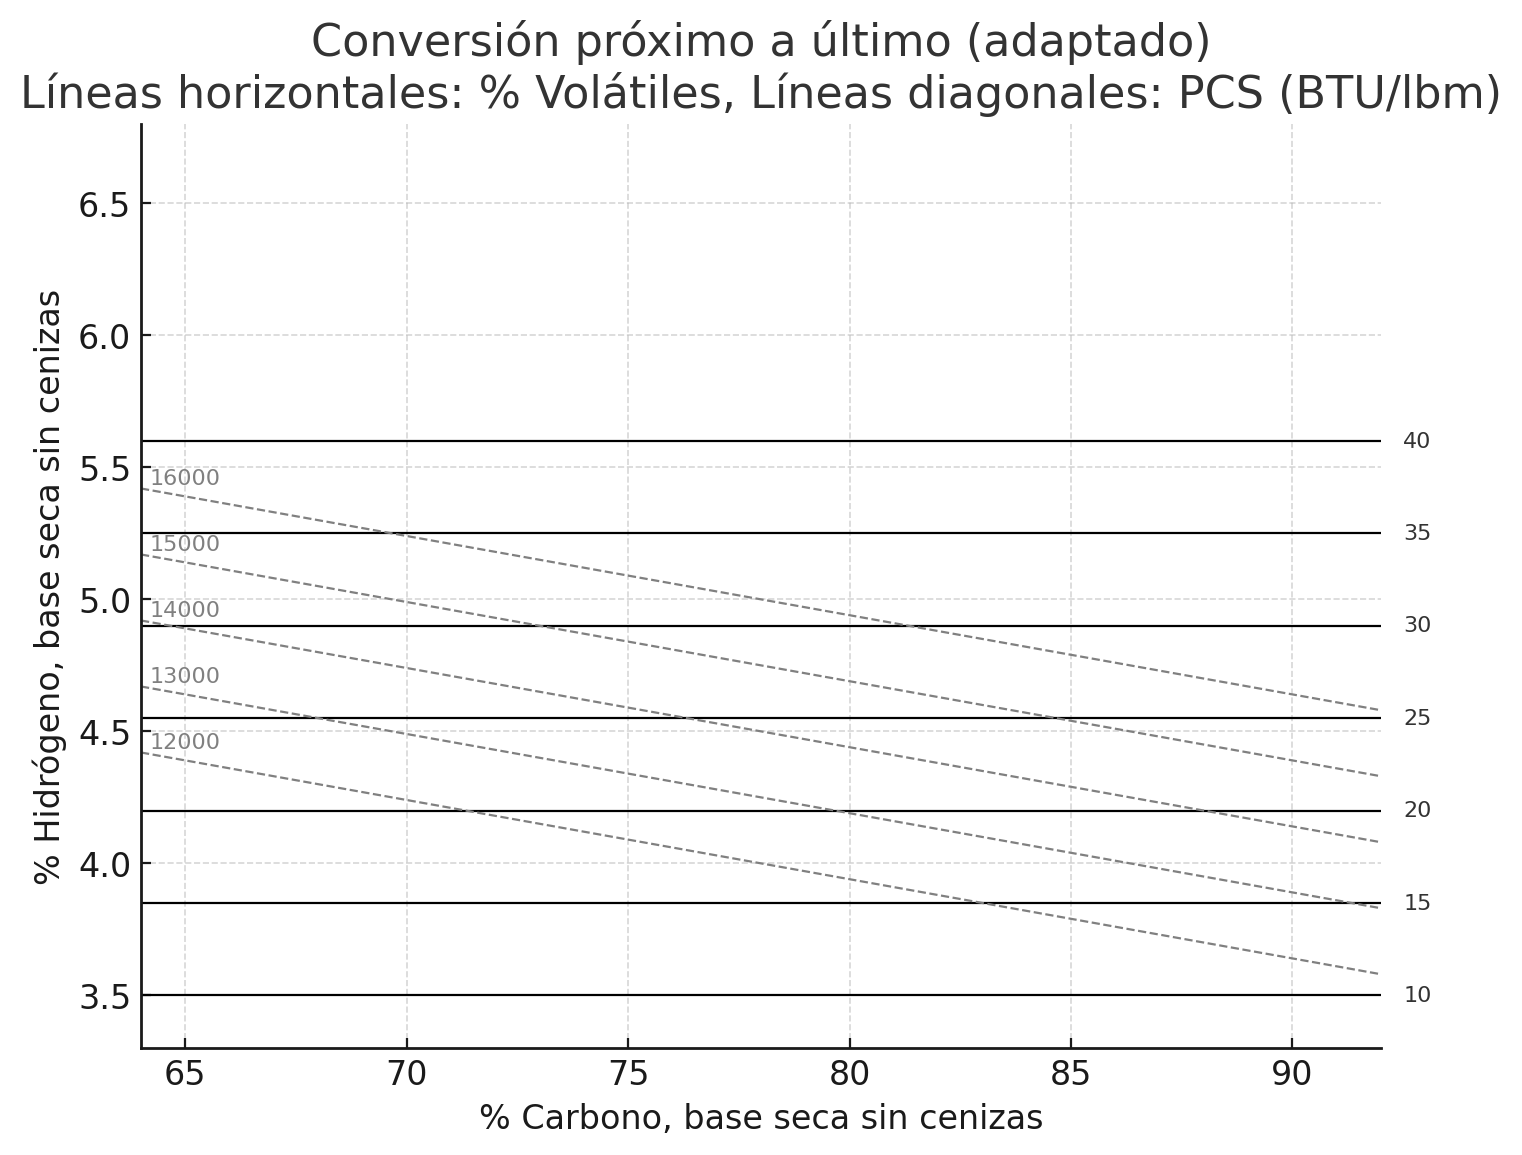

###10.5 Calidad del combustible

La calidad del combustible se refiere a las características físicas y químicas de un combustible que determinan su utilidad y eficiencia. Las características que se consideran al evaluar la calidad del combustible pueden incluir el contenido de energía, la tasa de combustión, la producción de humo y la producción de cenizas.

La calidad del combustible puede ser afectada por varios factores, incluyendo la fuente de la materia prima, el proceso de producción, el almacenamiento y el transporte. Por lo tanto, es importante realizar un análisis regular de la calidad del combustible para asegurar su rendimiento y eficiencia.
